In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('customer_churn.xlsx')
df.head()


,CustomerID,Count,Country,State,City,Zip Code,Gender,Senior Citizen,Partner,Dependents,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,Male,No,No,No,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,Female,No,No,Yes,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,Female,No,No,Yes,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,Female,No,Yes,Yes,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,Male,No,No,Yes,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Gender             7043 non-null   object 
 7   Senior Citizen     7043 non-null   object 
 8   Partner            7043 non-null   object 
 9   Dependents         7043 non-null   object 
 10  Tenure Months      7043 non-null   int64  
 11  Phone Service      7043 non-null   object 
 12  Multiple Lines     7043 non-null   object 
 13  Internet Service   7043 non-null   object 
 14  Online Security    7043 non-null   object 
 15  Online Backup      7043 non-null   object 
 16  Device Protection  7043 

In [4]:
print("Dataset Shape:", df.shape)
print("Column Names:", df.columns.tolist())
print("Missing values in each column:\n", df.isnull().sum())

Dataset Shape: (7043, 30)
Column Names: ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']
Missing values in each column:
 CustomerID           0
Count                0
Country              0
State                0
City                 0
Zip Code             0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract      

In [5]:
#Convert Data type to float
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'] = df['Total Charges'].astype('float64')

In [6]:
# Use \s* to catch ZERO or more spaces (including empty strings '')
df['Total Charges'] = df['Total Charges'].replace(r'^\s*$', np.nan, regex=True)

# Explicitly call this to handle the deprecation and update the dtypes correctly
df = df.infer_objects(copy=False)

# Now check again
print(f"Number of blank values: {df['Total Charges'].isna().sum()}")


Number of blank values: 11


In [7]:
df['Total Charges'] = df['Total Charges'].fillna(0)
df['Total Charges'] = df['Total Charges'].astype(float)

In [8]:
# Defining Frequency
cols_fix = ['Phone Service', 'Multiple Lines', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies']

df[cols_fix] = df[cols_fix].replace({'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0})
#

/tmp/ipykernel_375/597674499.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[cols_fix] = df[cols_fix].replace({'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0})


In [9]:
df['Total Frequency'] = df[cols_fix].sum(axis=1)

In [10]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Gender,Senior Citizen,Partner,Dependents,...,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,Total Frequency
0,3668-QPYBK,1,United States,California,Los Angeles,90003,Male,No,No,No,...,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer,3
1,9237-HQITU,1,United States,California,Los Angeles,90005,Female,No,No,Yes,...,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved,1
2,9305-CDSKC,1,United States,California,Los Angeles,90006,Female,No,No,Yes,...,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved,5
3,7892-POOKP,1,United States,California,Los Angeles,90010,Female,No,Yes,Yes,...,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved,6
4,0280-XJGEX,1,United States,California,Los Angeles,90015,Male,No,No,Yes,...,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices,6


In [11]:
cols_final = ['CustomerID', 'Tenure Months', 'Total Frequency', 'Total Charges', 'Churn Label']
df_final = df[cols_final]
df_final.head()

,CustomerID,Tenure Months,Total Frequency,Total Charges,Churn Label
0,3668-QPYBK,2,3,108.15,Yes
1,9237-HQITU,2,1,151.65,Yes
2,9305-CDSKC,8,5,820.50,Yes
3,7892-POOKP,28,6,3046.05,Yes
4,0280-XJGEX,49,6,5036.30,Yes


In [12]:
# RFM Score
#R_Score (Tenure)
df['R_Score'] = pd.qcut(df['Tenure Months'], 5, labels=[1,2,3,4,5])
print(f"R-Score: {df['R_Score'].head()}")
#F_Score (Frequency/Service Count)
df['F_Score'] = pd.qcut(df['Total Frequency'], 5, labels=[1, 2, 3, 4, 5])
print(f"F-Score: {df['F_Score'].head()}")
#M_Score (Total Charges)
df['M_Score'] = pd.qcut(df['Total Charges'], 5, labels=[1,2,3,4,5])
print(f"M-Score: {df['M_Score'].head()}")
# Combined RFM Score
df['RFM_Score'] = df['R_Score'].astype(str) + df['F_Score'].astype(str) + df['M_Score'].astype(str)
print(f"RFM Score: {df['RFM_Score'].head()}")

R-Score: 0    1
1    1
2    2
3    3
4    4
Name: R_Score, dtype: category
Categories (5, int64): [1 < 2 < 3 < 4 < 5]
F-Score: 0    3
1    1
2    4
3    5
4    5
Name: F_Score, dtype: category
Categories (5, int64): [1 < 2 < 3 < 4 < 5]
M-Score: 0    1
1    1
2    2
3    4
4    5
Name: M_Score, dtype: category
Categories (5, int64): [1 < 2 < 3 < 4 < 5]
RFM Score: 0    131
1    111
2    242
3    354
4    455
Name: RFM_Score, dtype: object


In [13]:
def customer_segment(row):
  r,f,m = int(row['R_Score']), int(row['F_Score']), int(row['M_Score'])

  #Champions - best customers
  if r>= 4 and f>=4 and m>=4:
    return 'Champions'
  #At Risk(Starting to Churn)
  elif r>=4 and f>=2 and m>=4:
    return 'At Risk'
  #Lost Customer (Low on everything)
  elif r<=2 and f<=2 and m<=2:
    return 'Lost Customer'
  #New Customer (Not enough frequency)
  elif r>=4 and f<=2 and m<=4:
    return 'New Customer'
  else:
    return 'Standard'
df['customer_segment'] = df.apply(customer_segment, axis=1)
print(f"Customer Segment: {df['customer_segment'].head()}")
print(df['customer_segment'].value_counts())

Customer Segment: 0         Standard
1    Lost Customer
2         Standard
3         Standard
4        Champions
Name: customer_segment, dtype: object
customer_segment
Standard         2589
Lost Customer    1710
Champions        1539
New Customer      605
At Risk           600
Name: count, dtype: int64


In [14]:
segment_churn_report = pd.crosstab(
    df['customer_segment'],
    df['Churn Label'],
    normalize='index',
    margins=True
)*100

segment_churn_report = segment_churn_report.sort_values(by='Yes', ascending=False)
print(segment_churn_report[['Yes']].round(2))

Churn Label         Yes
customer_segment       
Lost Customer     38.95
Standard          34.76
All               26.54
At Risk           15.17
Champions         12.87
New Customer       2.31


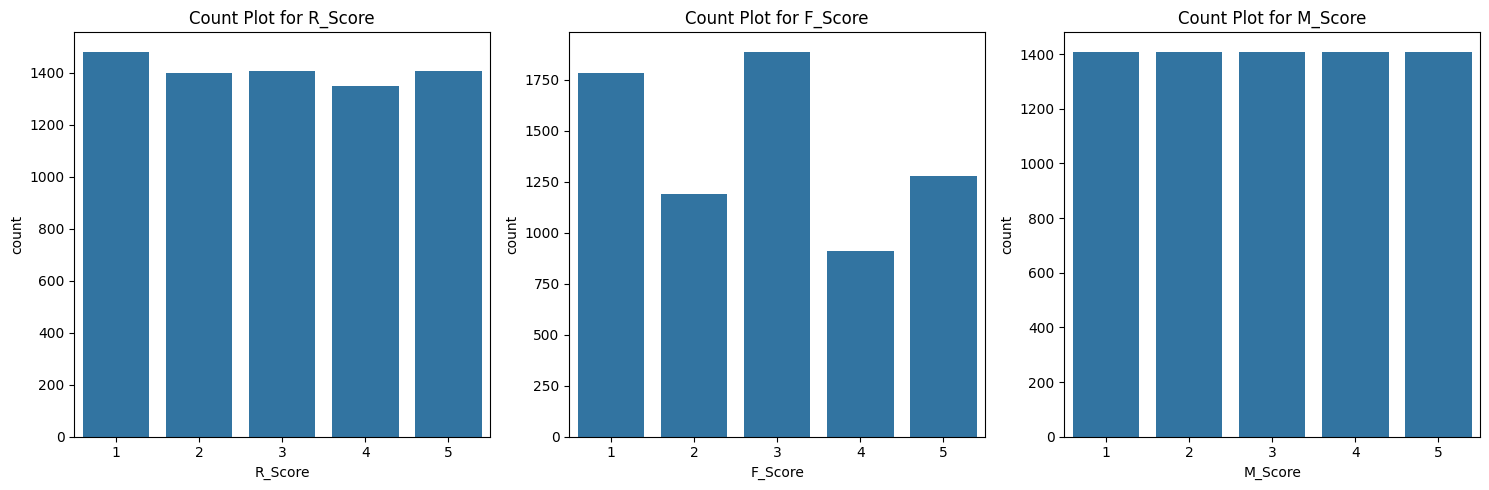

In [15]:
#Vizualzing RFM Scores
fig, axes = plt.subplots(1,3, figsize=(15,5))

for i, col in enumerate(['R_Score', 'F_Score', 'M_Score']):
  sns.countplot(x=df[col], ax=axes[i])
  axes[i].set_title(f'Count Plot for {col}')

plt.tight_layout()
plt.show()

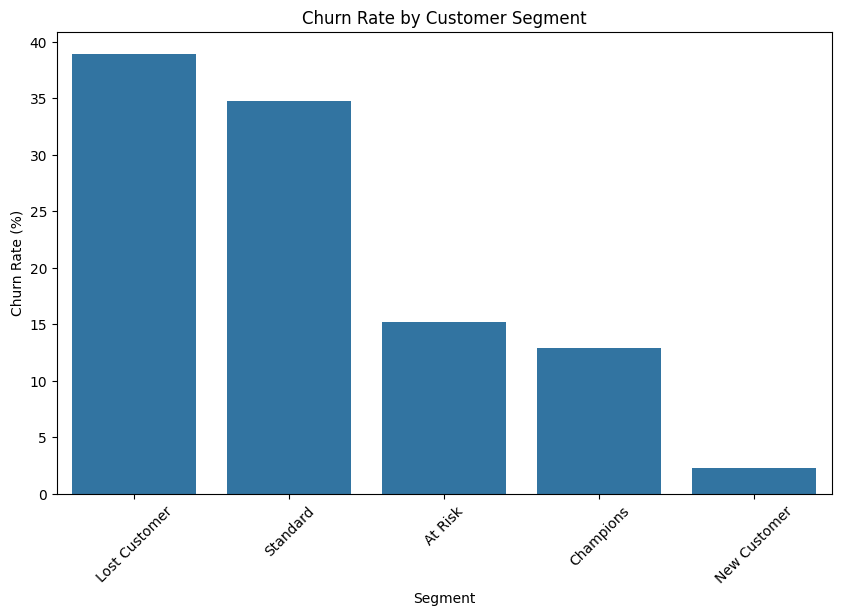

In [16]:
#Vizualization of Churn Rate by Segment
churn_rates = df.groupby('customer_segment')['Churn Label'].value_counts(normalize=True).unstack()['Yes']*100
churn_rates = churn_rates.sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=churn_rates.index, y=churn_rates.values)
plt.xlabel('Segment')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Customer Segment')
plt.xticks(rotation=45)
plt.show()

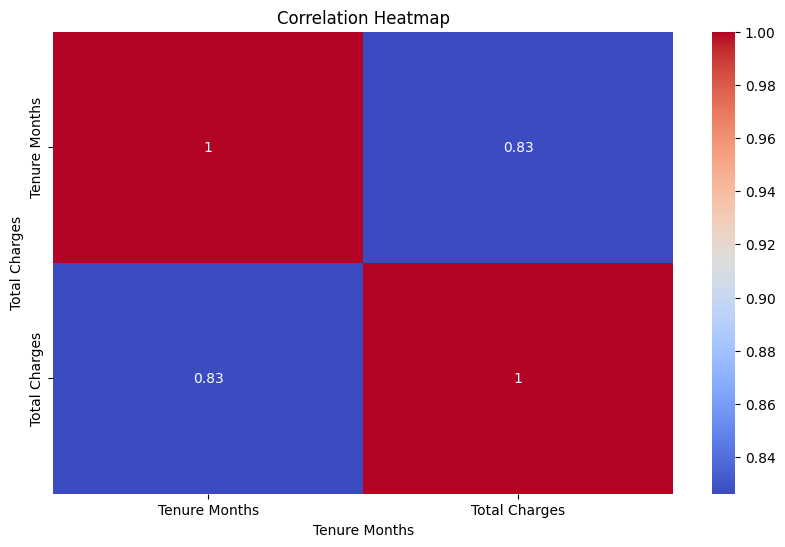

In [17]:
#Tenure vs Total Charges Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df[['Tenure Months', 'Total Charges']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.xlabel('Tenure Months')
plt.ylabel('Total Charges')
plt.show()




In [20]:
df_final.to_excel('phase2_customer_churn.xlsx', index=False)
from google.colab import files
files.download('phase2_customer_churn.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>